# Diabetes Veri Seti ile Linear Regression

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#Serpilme Diyagramı Çizme

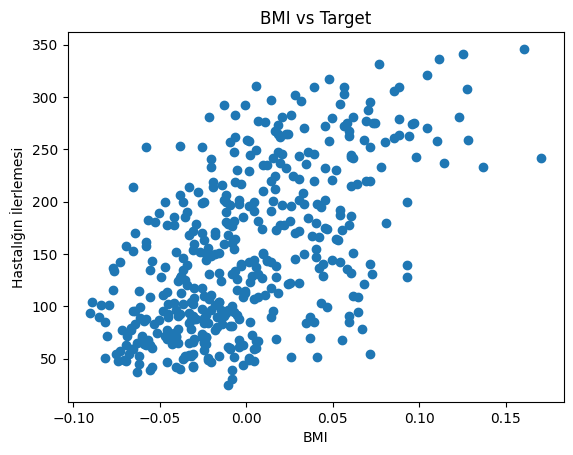

In [3]:
bmi = X[:, 2]

# Scatter plot
plt.figure()
plt.scatter(bmi, y)
plt.xlabel("BMI")
plt.ylabel("Hastalığın İlerlemesi")
plt.title("BMI vs Target")
plt.show()

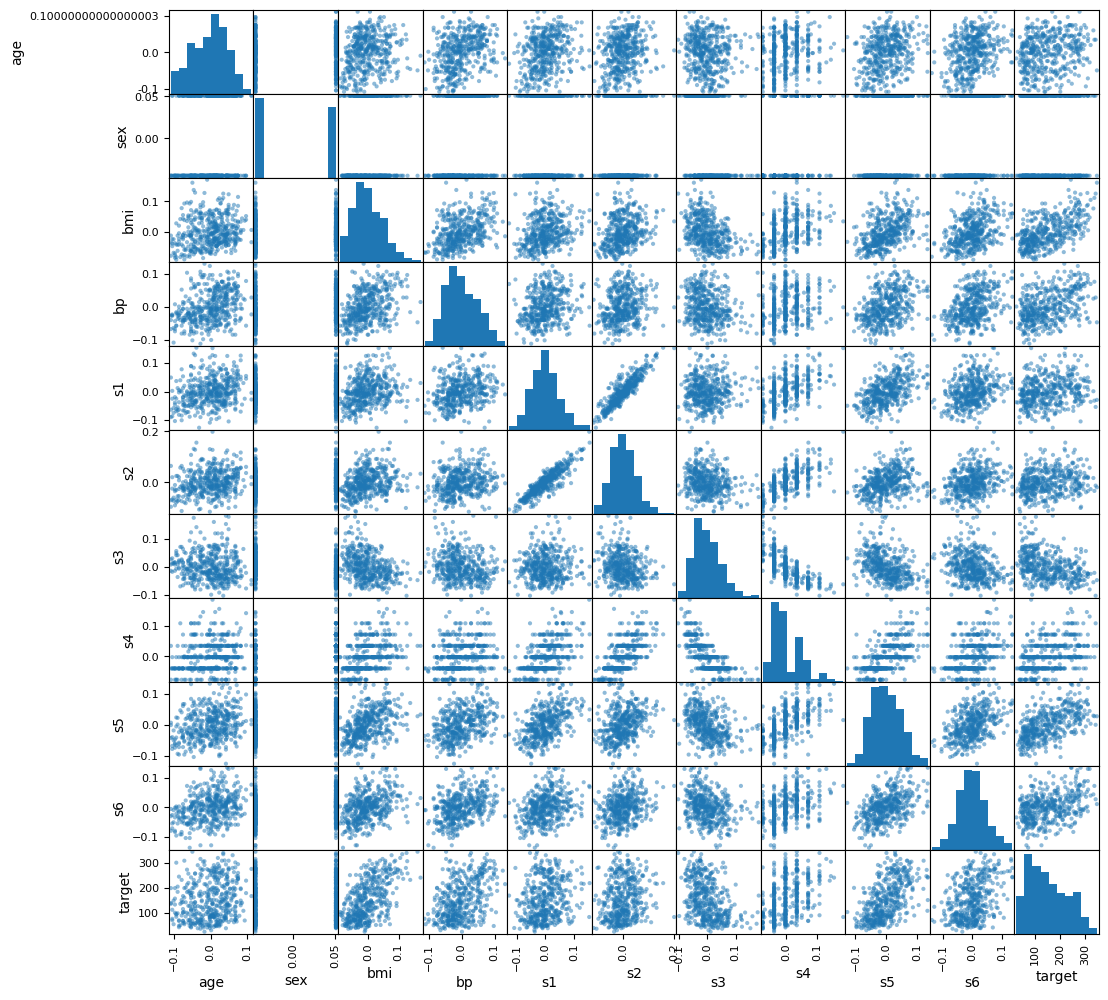

In [4]:
df = pd.DataFrame(X, columns=diabetes.feature_names)
df["target"] = y

pd.plotting.scatter_matrix(df, figsize=(12, 12))
plt.show()

# Pipeline


In [5]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])


# Hyperparameter tuning

In [6]:
param_grid = {
    "model__fit_intercept": [True, False],
    "model__positive": [True, False]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="r2")
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)


Best Params: {'model__fit_intercept': True, 'model__positive': False}


#Tahmin

In [7]:
y_pred = best_model.predict(X_test)

# Model Gelişimi

In [8]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)


MSE: 2821.750981001311
R2: 0.4772897164322617


#Actual vs Predicted Plot
“Actual vs Predicted” grafiği, modelin gerçek değerleri ne kadar iyi tahmin ettiğini görselleştirir. Yani performansı sezgisel olarak anlamanı sağlar.

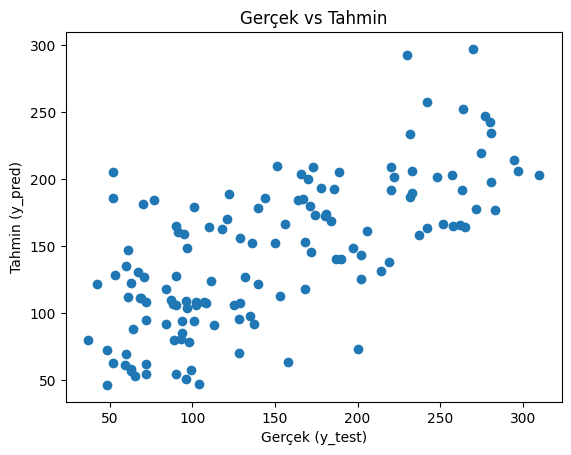

In [9]:

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Gerçek (y_test)")
plt.ylabel("Tahmin (y_pred)")
plt.title("Gerçek vs Tahmin")
plt.show()


#Residual Plot
Residual plot (artık grafiği), modelin yaptığı hataların yapısını analiz etmeni sağlar. Bu grafik, doğrusal regresyonun varsayımlarının sağlanıp sağlanmadığını test etmek için kritik bir araçtır.

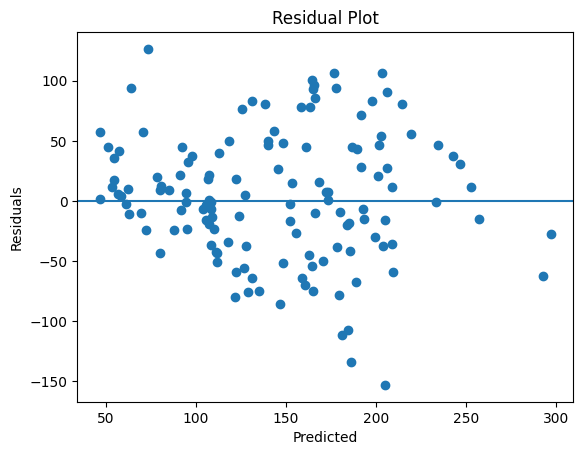

In [10]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


#Coefficients
Coefficients (katsayılar), doğrusal regresyon modelinde her bir özelliğin (feature) hedef değişken üzerindeki etkisini ve yönünü verir. Modelin “neye göre karar verdiğini” anlamanın en doğrudan yoludur.

In [11]:
feature_names = diabetes.feature_names
coefficients = best_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

coef_df


,Feature,Coefficient
8,s5,31.575215
2,bmi,26.210046
5,s2,24.255629
3,bp,18.614433
7,s4,13.963427
6,s3,5.738626
9,s6,1.983394
0,age,1.352467
1,sex,-12.454269
4,s1,-43.260394
